In [1]:
from einops import rearrange, einsum, pack
import torch
import math
from utils import init_custom_weight, inspect_tensor
from tokenizerModule import ID_mapper
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image



Image generated: (100, 100)


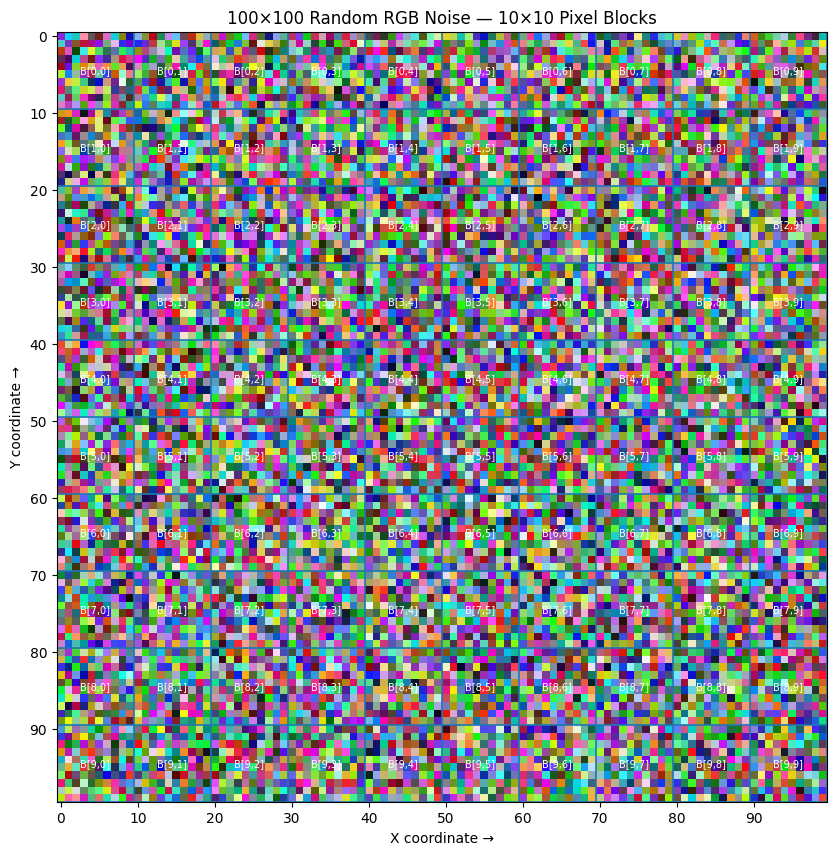

RGB values written to: random_noise_rgb_values.txt


In [4]:
# --- PROOF OF HUMANITY ---


# Reproducibility
rng = np.random.default_rng(42)

# Image dimensions
IMAGE_WIDTH  = 100
IMAGE_HEIGHT = 100
BLOCK_SIZE   = 10

# Generate random RGB values
# Shape: [height, width, RGB]
image_array = rng.integers(
    low=0,
    high=256,
    size=(IMAGE_HEIGHT, IMAGE_WIDTH, 3),
    dtype=np.uint8
)

# Convert to PIL image
image = Image.fromarray(image_array, mode="RGB")

# Save image
image.save("random_noise_100x100.png")

print("Image generated:", image.size)


# ---------

fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(image_array)

# Draw block boundaries every 10 pixels
for x in range(0, IMAGE_WIDTH + 1, BLOCK_SIZE):
    ax.axvline(x - 0.5, linewidth=1.2)

for y in range(0, IMAGE_HEIGHT + 1, BLOCK_SIZE):
    ax.axhline(y - 0.5, linewidth=1.2)

# Label each 10x10 block
for block_y in range(10):
    for block_x in range(10):
        center_x = block_x * BLOCK_SIZE + BLOCK_SIZE / 2 - 0.5
        center_y = block_y * BLOCK_SIZE + BLOCK_SIZE / 2 - 0.5

        ax.text(
            center_x,
            center_y,
            f"B[{block_y},{block_x}]",
            ha="center",
            va="center",
            fontsize=7,
            color="white"
        )

# Pixel coordinate ticks
ax.set_xticks(range(0, IMAGE_WIDTH, 10))
ax.set_yticks(range(0, IMAGE_HEIGHT, 10))

ax.set_xlabel("X coordinate →")
ax.set_ylabel("Y coordinate →")
ax.set_title("100×100 Random RGB Noise — 10×10 Pixel Blocks")

plt.show()


# --------------

text_filename = "random_noise_rgb_values.txt"

with open(text_filename, "w") as f:

    f.write("100x100 RANDOM RGB IMAGE\n")
    f.write("=" * 60 + "\n")
    f.write("Coordinate system: (x, y)\n")
    f.write("x = left -> right\n")
    f.write("y = top -> bottom\n")
    f.write("Pixel order: left-to-right, top-to-bottom\n")
    f.write("Block size: 10x10 pixels\n")
    f.write("=" * 60 + "\n\n")

    for y in range(IMAGE_HEIGHT):

        # Start a section for every image row
        f.write(f"Y = {y}\n")

        for x in range(IMAGE_WIDTH):

            r, g, b = image_array[y, x]

            # Determine which 10x10 block contains this pixel
            block_x = x // BLOCK_SIZE
            block_y = y // BLOCK_SIZE

            f.write(
                f"(x={x:02d}, y={y:02d}) "
                f"[Block={block_y},{block_x}] "
                f"RGB=({int(r):3d}, {int(g):3d}, {int(b):3d})\n"
            )

        f.write("\n")

print(f"RGB values written to: {text_filename}")


In [9]:
x =[
    [1,2,3,4,5,6,7,8,9,10],
    [1,2,3,4,5,6,7,8,9,10],
    [1,2,3,4,5,6,7,8,9,10],
]

x[ : , :4]

TypeError: list indices must be integers or slices, not tuple

In [2]:
x = torch.empty(3,4)
init_custom_weight(x, is_residual_output=False)
inspect_tensor(x, name="Linear_Proj_Weight", category="weight").print_summary()


=== Linear_Proj_Weight [WEIGHT] Status: HEALTHY ===
Metrics:
  - numel: 12
  - mean: 3.771693e-03
  - std: 1.551946e-02
  - var: 2.408537e-04
  - min: -2.801843e-02
  - max: 3.615297e-02
  - l2_norm: 5.532587e-02
  - zero_fraction: 0.000000e+00
  - nan_count: 0
  - inf_count: 0
  - outlier_ratio_3sigma: 0.000000e+00



In [3]:
# powers of 2 
for i in range(15):
    print(f"2**{i} = {2**i}")

2**0 = 1
2**1 = 2
2**2 = 4
2**3 = 8
2**4 = 16
2**5 = 32
2**6 = 64
2**7 = 128
2**8 = 256
2**9 = 512
2**10 = 1024
2**11 = 2048
2**12 = 4096
2**13 = 8192
2**14 = 16384


In [2]:
from tokenizerModule import ID_mapper


prompt_to_IDs = ID_mapper.encode("hello, how are you?")

# torch tensor
# x = torch.tensor(prompt_to_IDs).unsqueeze(0)  # Add batch dimension

# x = torch.tensor()


# print(x)

In [3]:
import training_engine as training_engine

loader = training_engine.BatchLoader("train", max_batch_size=1, max_seq_len=12, device='cuda')
x, y = loader.get_batch()
print(x)
print("-"*80)
print(y)


tensor([[ 145,  415,  887, 1457,  145,  204,   38, 1427,  144,  267,  603, 1417]],
       device='cuda:0')
--------------------------------------------------------------------------------
tensor([[ 415,  887, 1457,  145,  204,   38, 1427,  144,  267,  603, 1417,   96]],
       device='cuda:0')


In [33]:
w = torch.randn(3,(2*2))
x = torch.randn(1,3)

# y = einsum(x,w, "b d, i o -> b o")
y = einsum(x,w, "b d, i o "
                " -> "
                "b o"
                )
y

tensor([[-1.2723, -5.9210,  4.6493,  1.4152]])

In [12]:
x = torch.tensor([[1430,  787,  138,  379,   68,  264,   52,  395],
        [1430,  787, 1776, 1574,  225,  198,  398, 1115],
        [1430,  787, 1776, 1574,  225,  198,  398, 1115]])

seq = x

xx = torch.tensor([[225],[787],[1776]]) # [3,1]
seq, dim = pack([seq, xx], "batch_size *")
seq.shape


torch.Size([3, 9])

In [ ]:
# einops



In [26]:
torch.arange(1,10)

tensor([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [28]:
print(torch.cuda.get_device_capability())
print(torch.backends.cuda.is_flash_attention_available())


(7, 5)
False


In [30]:
mask = torch.triu(
            torch.ones(8,8, dtype=torch.bool),
            diagonal=1,
        )

mask

tensor([[False,  True,  True,  True,  True,  True,  True,  True],
        [False, False,  True,  True,  True,  True,  True,  True],
        [False, False, False,  True,  True,  True,  True,  True],
        [False, False, False, False,  True,  True,  True,  True],
        [False, False, False, False, False,  True,  True,  True],
        [False, False, False, False, False, False,  True,  True],
        [False, False, False, False, False, False, False,  True],
        [False, False, False, False, False, False, False, False]])

In [38]:
n_q = 2
n_kv = 2

b = 1
seq = 5
emb = 4


q = torch.randn(b, n_q,seq,  emb)
k = torch.randn(b, n_kv,seq, emb)
v = torch.rand( b, n_kv,seq, emb)


# (q_T k)/
out = torch.nn.functional.scaled_dot_product_attention(
            q, k, v,
            is_causal=True,
            # enable_gqa=(n_q != n_kv),
        )

print(out.shape)
print(out)

torch.Size([1, 2, 5, 4])
tensor([[[[0.9710, 0.6136, 0.0883, 0.6372],
          [0.3250, 0.1750, 0.7575, 0.1427],
          [0.7467, 0.4510, 0.4586, 0.3118],
          [0.7578, 0.4153, 0.4029, 0.4250],
          [0.8554, 0.5429, 0.2354, 0.5380]],

         [[0.7721, 0.3102, 0.1343, 0.2563],
          [0.1884, 0.8463, 0.1459, 0.1600],
          [0.4192, 0.2950, 0.4757, 0.4246],
          [0.6278, 0.3346, 0.2332, 0.2611],
          [0.2508, 0.3512, 0.5933, 0.3756]]]])


In [39]:
attention_scores = einsum(
    q, k,
    "batch num_heads query_len head_dim, "
    "batch num_heads key_len head_dim "
    "-> batch num_heads query_len key_len",
)

attention_scores = attention_scores / math.sqrt(q.shape[-1])

causal_mask = torch.tril(
        torch.ones(
            seq,
            seq,
            dtype=torch.bool,
            device=q.device,
        )
    )

attention_scores = attention_scores.masked_fill(
    ~causal_mask,
    float("-inf"),
)

attention_weights = torch.nn.functional.softmax(
    attention_scores,
    dim=-1,
)

print(attention_weights)


output = einsum(
    attention_weights, v,
    "batch num_heads query_len key_len, "
    "batch num_heads key_len head_dim "
    "-> batch num_heads query_len head_dim",
)
print("---"*80)
print(output)

tensor([[[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.2170, 0.7830, 0.0000, 0.0000, 0.0000],
          [0.0620, 0.1973, 0.7407, 0.0000, 0.0000],
          [0.4938, 0.2542, 0.0540, 0.1980, 0.0000],
          [0.7443, 0.0955, 0.0102, 0.0976, 0.0523]],

         [[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.0736, 0.9264, 0.0000, 0.0000, 0.0000],
          [0.4921, 0.1106, 0.3973, 0.0000, 0.0000],
          [0.7576, 0.0920, 0.0709, 0.0795, 0.0000],
          [0.0783, 0.2316, 0.3626, 0.2461, 0.0813]]]])
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
tensor([[[[0.9710, 0.6136, 0.0883, 0.6372],
          [0.3250, 0.1750, 0.7575, 0.1427],
          [0.7467, 0.4510, 0.4586, 0.3118],
          [0.7578, 0.4153, 0.4029, 0.4250],
          [0.8554, 0.5429, 0.2354, 0.5380]],

         [[0

In [54]:
h = 32//4

inv_freq = 1.0 / (
            1000 ** (torch.arange(0, h, 2, device='cuda').float() / h)
        )

print(inv_freq.shape)
print(inv_freq)

torch.Size([4])
tensor([1.0000, 0.1778, 0.0316, 0.0056], device='cuda:0')


In [ ]:
x = torch.arange(0,10)
x.dim()==1

True